<p>Quantization-Aware Training (QAT) is the "gold standard" for shrinking models. While Post-Training Quantization (PTQ) tries to fix the model after it's done, QAT teaches the model to be accurate while being quantized.

Think of PTQ as trying to fit into a smaller suit after you've already bought it. QAT is like getting the suit tailor-made while you're still at your target weight.</p>

<p>1. How it Works: "Fake Quantization"
During the training process, QAT inserts Fake Quantization nodes into the model.

Forward Pass: The weights and activations are rounded to their low-precision values (e.g., INT8). This introduces "quantization noise," forcing the model to learn weights that are resilient to rounding errors.

Backward Pass: Since rounding is a non-differentiable operation (you can't take a derivative of a step function), QAT uses a Straight-Through Estimator (STE). It essentially "pretends" the rounding didn't happen for the gradient, allowing the model to update its weights normally.</p>

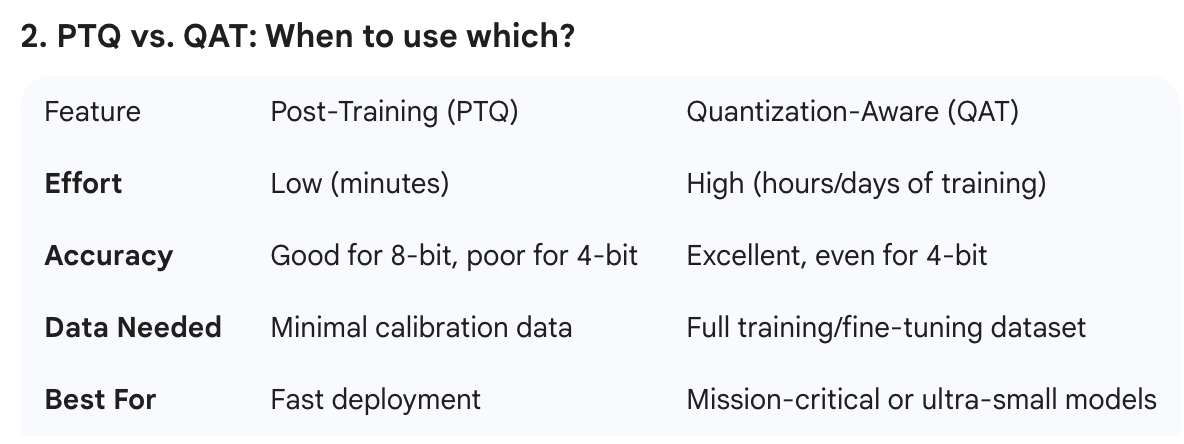

<p>3. Implementation with optimum-quanto
To perform QAT with BERT, you first "quantize" the model to prepare the fake nodes, then you perform a standard fine-tuning loop, and finally you "freeze" the weights into their true integer form.</p>

In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from transformers import BertForSequenceClassification, BertTokenizer
from optimum.quanto import quantize, freeze, qint8

# 1. Setup Environment & Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name).to(device)

# 2. CREATE THE MISSING DATALOADER (Dummy Data Example)
sentences = ["I love quantization!", "BERT is very large.", "Fast inference is key."]
labels = [1, 0, 1] # 1 = Positive, 0 = Negative

# Tokenize data
inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

# Create a PyTorch Dataset and Dataloader
dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], torch.tensor(labels))
train_dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# 3. Prepare for QAT
quantize(model, weights=qint8, activations=qint8)

# 4. QAT Training Loop
optimizer = AdamW(model.parameters(), lr=5e-5)
model.train()

for epoch in range(1): # Reduced to 1 for demonstration
    for batch in train_dataloader:
        optimizer.zero_grad()
        
        # Unpack batch and move to device
        b_input_ids, b_attn_mask, b_labels = [t.to(device) for t in batch]
        
        outputs = model(input_ids=b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()

# 5. Finalize the quantized model
freeze(model)

print(f"QAT Complete! Model size: {model.get_memory_footprint() / 1e6:.2f} MB")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


QAT Complete! Model size: 437.94 MB


<p>4. Why QAT is essential for 4-bitWhen you drop down to 4-bit ($16$ possible values), the "gap" between values is huge. In PTQ, this often causes the model's logic to collapse. QAT allows the model to shift its weight clusters so they land exactly on those 16 available points, preserving nearly all the original accuracy.4</p>